# Phase-1

# Import Required Libraries

In [5]:
# Data manipulation
import numpy as np
import pandas as pd

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Data preprocessing
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Machine Learning Model
from sklearn.linear_model import LogisticRegression

# Model Evaluation
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

# Display plots inside notebook
%matplotlib inline

# Load the Dataset

In [6]:
# Load dataset
df = pd.read_csv("creditcard.csv")

# Understand the Dataset

In [7]:
# Shape of dataset
print("Dataset Shape:", df.shape)

# Number of rows and columns
print("Number of Rows:", df.shape[0])
print("Number of Columns:", df.shape[1])

# Display column names
print(df.columns.tolist())

Dataset Shape: (284807, 31)
Number of Rows: 284807
Number of Columns: 31
['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']


In [8]:
# Dataset information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [9]:
# Display first five rows
df.head()


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [10]:
# Display last five rows
df.tail()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
284802,172786.0,-11.881118,10.071785,-9.834783,-2.066656,-5.364473,-2.606837,-4.918215,7.305334,1.914428,...,0.213454,0.111864,1.014480,-0.509348,1.436807,0.250034,0.943651,0.823731,0.77,0
284803,172787.0,-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,0.584800,...,0.214205,0.924384,0.012463,-1.016226,-0.606624,-0.395255,0.068472,-0.053527,24.79,0
284804,172788.0,1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,0.432454,...,0.232045,0.578229,-0.037501,0.640134,0.265745,-0.087371,0.004455,-0.026561,67.88,0
284805,172788.0,-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,0.392087,...,0.265245,0.800049,-0.163298,0.123205,-0.569159,0.546668,0.108821,0.104533,10.00,0
284806,172792.0,-0.533413,-0.189733,0.703337,-0.506271,-0.012546,-0.649617,1.577006,-0.414650,0.486180,...,0.261057,0.643078,0.376777,0.008797,-0.473649,-0.818267,-0.002415,0.013649,217.00,0


In [11]:
# Random sample of five records
df.sample(5, random_state=42)

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
43428,41505.0,-16.526507,8.584972,-18.649853,9.505594,-13.793819,-2.832404,-16.701694,7.517344,-8.507059,...,1.190739,-1.127670,-2.358579,0.673461,-1.413700,-0.462762,-2.018575,-1.042804,364.19,1
49906,44261.0,0.339812,-2.743745,-0.134070,-1.385729,-1.451413,1.015887,-0.524379,0.224060,0.899746,...,-0.213436,-0.942525,-0.526819,-1.156992,0.311211,-0.746647,0.040996,0.102038,520.12,0
29474,35484.0,1.399590,-0.590701,0.168619,-1.029950,-0.539806,0.040444,-0.712567,0.002299,-0.971747,...,0.102398,0.168269,-0.166639,-0.810250,0.505083,-0.232340,0.011409,0.004634,31.00,0
276481,167123.0,-0.432071,1.647895,-1.669361,-0.349504,0.785785,-0.630647,0.276990,0.586025,-0.484715,...,0.358932,0.873663,-0.178642,-0.017171,-0.207392,-0.157756,-0.237386,0.001934,1.50,0
278846,168473.0,2.014160,-0.137394,-1.015839,0.327269,-0.182179,-0.956571,0.043241,-0.160746,0.363241,...,-0.238644,-0.616400,0.347045,0.061561,-0.360196,0.174730,-0.078043,-0.070571,0.89,0


In [12]:
df.shape
# Phase-1 succesfully completed

(284807, 31)

# Phase-2 -----------> Exploratory Data Analysis (EDA)

In [13]:
# Check missing values
missing_values = df.isnull().sum()

print("Missing Values in Each Column:")
print(missing_values)

Missing Values in Each Column:
Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64


In [14]:
# Total missing values
print("Total Missing Values:", df.isnull().sum().sum())

Total Missing Values: 0


In [15]:
# Number of duplicate rows
duplicates = df.duplicated().sum()

print("Duplicate Records:", duplicates)

Duplicate Records: 1081


In [16]:
# Remove duplicate rows if any exist
df = df.drop_duplicates()

print("Dataset Shape After Removing Duplicates:", df.shape)

Dataset Shape After Removing Duplicates: (283726, 31)


In [17]:
# Statistical Summary
#Generate descriptive statistics to understand the distribution of numerical features such as mean, standard deviation, minimum, maximum, and quartiles.
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Time,283726.0,94811.077600,47481.047891,0.000000,54204.750000,84692.500000,139298.000000,172792.000000
V1,283726.0,0.005917,1.948026,-56.407510,-0.915951,0.020384,1.316068,2.454930
V2,283726.0,-0.004135,1.646703,-72.715728,-0.600321,0.063949,0.800283,22.057729
V3,283726.0,0.001613,1.508682,-48.325589,-0.889682,0.179963,1.026960,9.382558
V4,283726.0,-0.002966,1.414184,-5.683171,-0.850134,-0.022248,0.739647,16.875344
V5,283726.0,0.001828,1.377008,-113.743307,-0.689830,-0.053468,0.612218,34.801666
V6,283726.0,-0.001139,1.331931,-26.160506,-0.769031,-0.275168,0.396792,73.301626
V7,283726.0,0.001801,1.227664,-43.557242,-0.552509,0.040859,0.570474,120.589494
V8,283726.0,-0.000854,1.179054,-73.216718,-0.208828,0.021898,0.325704,20.007208
V9,283726.0,-0.001596,1.095492,-13.434066,-0.644221,-0.052596,0.595977,15.594995


In [18]:
# Class Distribution

# Analyze the distribution of genuine and fraudulent transactions. This helps determine whether the dataset is balanced or imbalanced.
df['Class'].value_counts()

Class
0    283253
1       473
Name: count, dtype: int64

In [19]:
# Percentage distribution
class_percentage = df['Class'].value_counts(normalize=True) * 100
print(class_percentage)

Class
0    99.83329
1     0.16671
Name: proportion, dtype: float64


# visualization

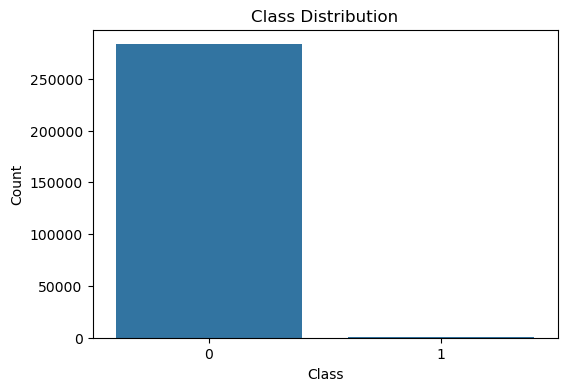

In [20]:
plt.figure(figsize=(6,4))
sns.countplot(x='Class', data=df)

plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Count")

plt.show()

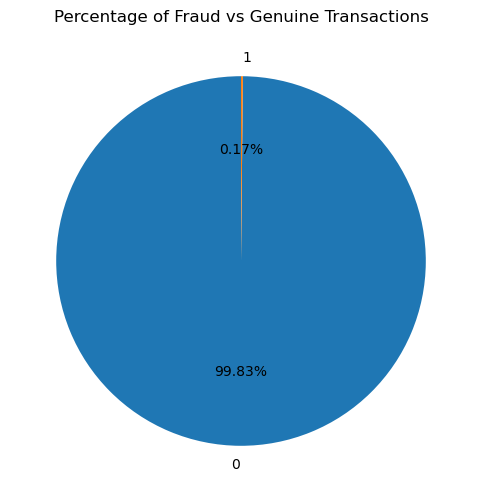

In [21]:
plt.figure(figsize=(6,6))

df['Class'].value_counts().plot(
    kind='pie',
    autopct='%1.2f%%',
    startangle=90
)

plt.ylabel("")
plt.title("Percentage of Fraud vs Genuine Transactions")

plt.show()

# Distribution of Transaction Amount

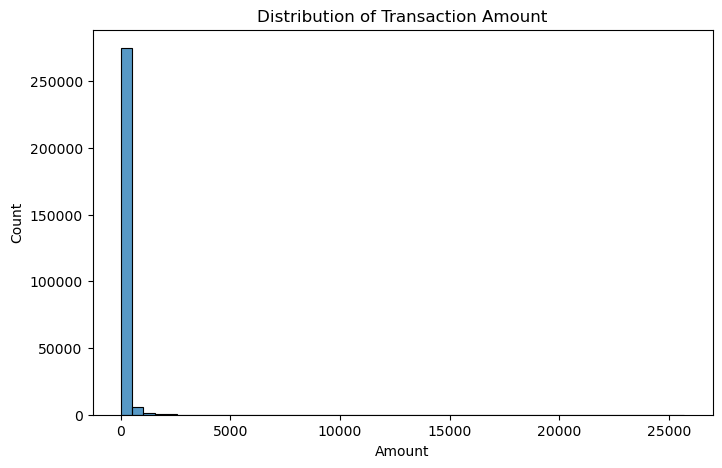

In [22]:
# Visualize the distribution of transaction amounts using histogram and boxplot.
plt.figure(figsize=(8,5))

sns.histplot(df['Amount'], bins=50)

plt.title("Distribution of Transaction Amount")
plt.xlabel("Amount")

plt.show()

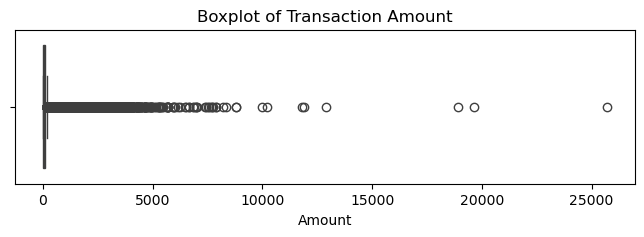

In [23]:
# Boxplot
plt.figure(figsize=(8,2))

sns.boxplot(x=df['Amount'])

plt.title("Boxplot of Transaction Amount")

plt.show()

# Distribution of Transaction Time

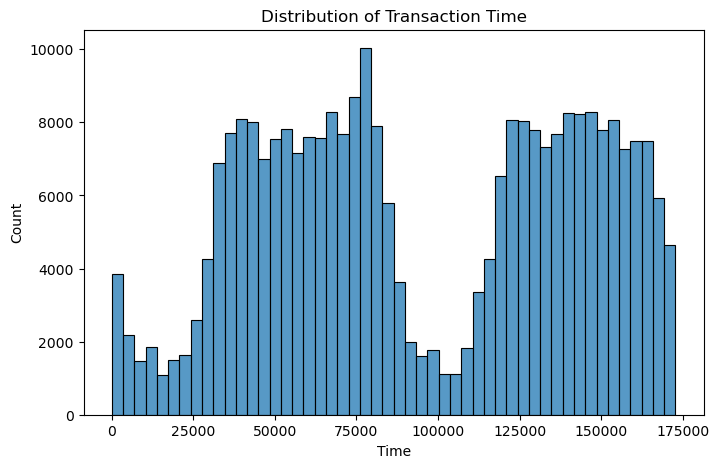

In [24]:
# Analyze how transactions are distributed over time.
# Histogram
plt.figure(figsize=(8,5))

sns.histplot(df['Time'], bins=50)

plt.title("Distribution of Transaction Time")
plt.xlabel("Time")

plt.show()

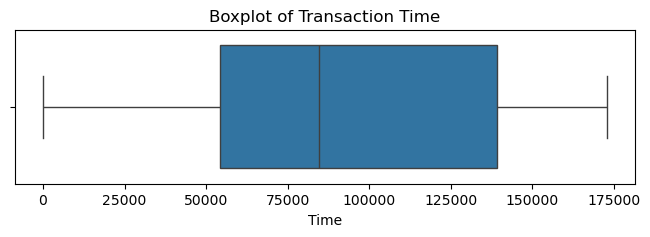

In [25]:
# oxplot
plt.figure(figsize=(8,2))

sns.boxplot(x=df['Time'])

plt.title("Boxplot of Transaction Time")

plt.show()

# Correlation Matrix

In [26]:
# Generate the correlation matrix to understand relationships between numerical features and identify any strong correlations.
correlation = df.corr()

correlation

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
Time,1.000000,0.117927,-0.010556,-0.422054,-0.105845,0.173223,-0.063279,0.085335,-0.038203,-0.007861,...,0.045913,0.143727,0.051474,-0.015954,-0.233262,-0.041818,-0.005171,-0.009305,-0.010559,-0.012359
V1,0.117927,1.000000,0.006875,-0.008112,0.002257,-0.007036,0.000413,-0.009173,-0.001168,0.001828,...,0.002818,-0.001436,-0.001330,-0.000723,-0.000222,-0.000684,-0.015706,-0.004861,-0.230105,-0.094486
V2,-0.010556,0.006875,1.000000,0.005278,-0.001495,0.005210,-0.000594,0.007425,0.002899,-0.000274,...,-0.004897,0.001237,-0.003855,0.000701,-0.001569,0.000253,0.007555,0.001611,-0.533428,0.084624
V3,-0.422054,-0.008112,0.005278,1.000000,0.002829,-0.006879,-0.001511,-0.011721,-0.001815,-0.003579,...,0.003500,-0.000275,0.000449,-0.000072,0.000425,-0.000094,-0.007051,-0.000134,-0.212410,-0.182322
V4,-0.105845,0.002257,-0.001495,0.002829,1.000000,0.001744,-0.000880,0.004657,0.000890,0.002154,...,-0.001034,0.000115,0.000732,-0.000120,0.000162,0.000777,0.001322,0.000231,0.099514,0.129326
V5,0.173223,-0.007036,0.005210,-0.006879,0.001744,1.000000,-0.000938,-0.008709,0.001430,-0.001213,...,0.001622,-0.000559,0.001183,0.000198,0.000069,0.000390,-0.005798,-0.000820,-0.387685,-0.087812
V6,-0.063279,0.000413,-0.000594,-0.001511,-0.000880,-0.000938,1.000000,0.000436,0.003036,-0.000734,...,-0.002134,0.001104,-0.000755,0.001202,0.000697,-0.000028,0.000289,0.000925,0.216389,-0.043915
V7,0.085335,-0.009173,0.007425,-0.011721,0.004657,-0.008709,0.000436,1.000000,-0.006419,-0.004921,...,0.009010,-0.002280,0.003303,-0.000384,-0.000072,0.000624,-0.004537,0.001657,0.400408,-0.172347
V8,-0.038203,-0.001168,0.002899,-0.001815,0.000890,0.001430,0.003036,-0.006419,1.000000,0.001038,...,0.018892,-0.006156,0.004994,0.000113,0.000011,-0.001407,0.000613,-0.000099,-0.104662,0.033068
V9,-0.007861,0.001828,-0.000274,-0.003579,0.002154,-0.001213,-0.000734,-0.004921,0.001038,1.000000,...,0.000679,0.000785,0.000677,-0.000103,-0.000275,0.001253,0.008221,0.005591,-0.044123,-0.094021


# Correlation Heatmap

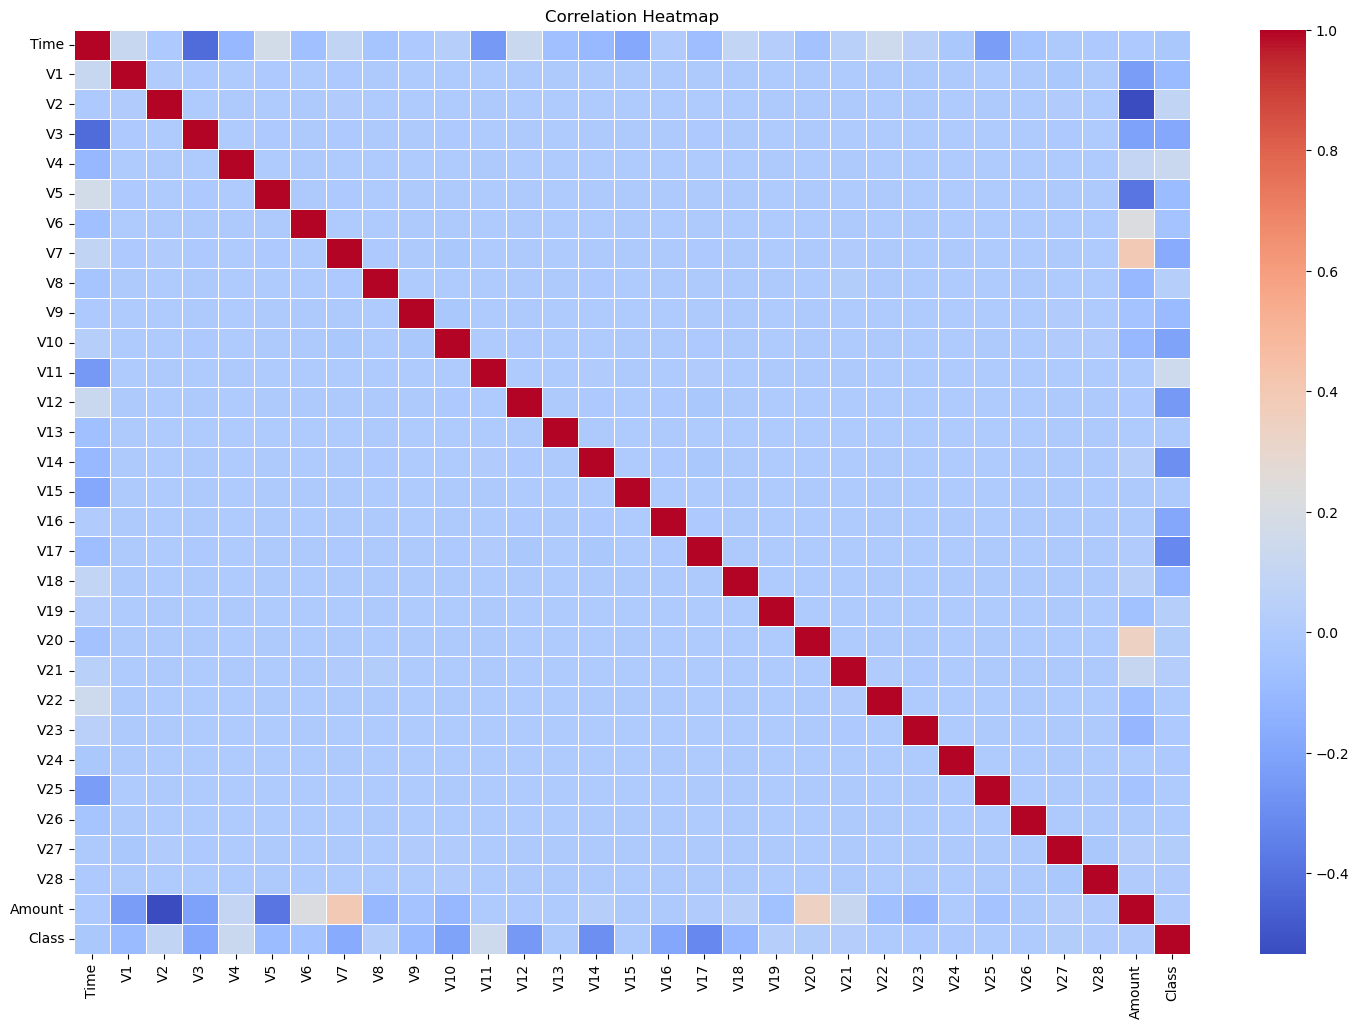

In [27]:
plt.figure(figsize=(18,12))

sns.heatmap(
    correlation,
    cmap='coolwarm',
    linewidths=0.5
)

plt.title("Correlation Heatmap")

plt.show()

# Correlation with Target Variable

In [28]:
# This is a very useful addition because it tells us which features are most associated with fraud.
# Display the correlation of all features with the target variable (Class).

In [29]:
corr_target = df.corr()['Class'].sort_values(ascending=False)

print(corr_target)

Class     1.000000
V11       0.149067
V4        0.129326
V2        0.084624
V19       0.033631
V8        0.033068
V21       0.026357
V27       0.021892
V20       0.021486
V28       0.009682
Amount    0.005777
V22       0.004887
V26       0.004265
V25       0.003202
V15      -0.003300
V13      -0.003897
V23      -0.006333
V24      -0.007210
Time     -0.012359
V6       -0.043915
V5       -0.087812
V9       -0.094021
V1       -0.094486
V18      -0.105340
V7       -0.172347
V3       -0.182322
V16      -0.187186
V10      -0.206971
V12      -0.250711
V14      -0.293375
V17      -0.313498
Name: Class, dtype: float64


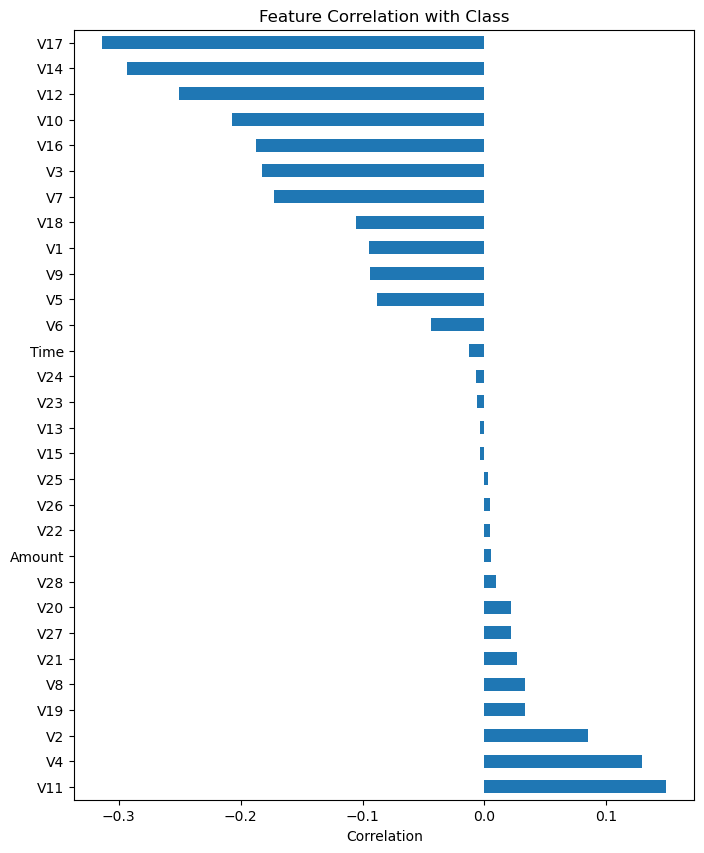

In [30]:
plt.figure(figsize=(8,10))

corr_target.drop('Class').plot(kind='barh')

plt.title("Feature Correlation with Class")

plt.xlabel("Correlation")

plt.show()

# Phase-3 -----------> Data preprocessing

# Feature Scaling

In [31]:
# Feature Scaling

# The `Amount` and `Time` features have different ranges compared to the PCA-transformed features (`V1` to `V28`). 
# To ensure all features contribute equally during model training, we standardize these two features using `StandardScaler`.

In [32]:
# Initialize StandardScaler
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

# Scale Amount and Time columns
df['Scaled_Amount'] = scaler.fit_transform(df[['Amount']])
df['Scaled_Time'] = scaler.fit_transform(df[['Time']])

# Display first five rows
df[['Amount', 'Scaled_Amount', 'Time', 'Scaled_Time']].head()

,Amount,Scaled_Amount,Time,Scaled_Time
0,149.62,0.244200,0.0,-1.996823
1,2.69,-0.342584,0.0,-1.996823
2,378.66,1.158900,1.0,-1.996802
3,123.50,0.139886,1.0,-1.996802
4,69.99,-0.073813,2.0,-1.996781


# Drop Original Columns

In [ ]:
# After scaling, the original `Amount` and `Time` columns are no longer required. They are removed to avoid redundancy.

In [33]:
# Drop original columns
df = df.drop(['Amount', 'Time'], axis=1)

# Display first five rows
df.head()

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V22,V23,V24,V25,V26,V27,V28,Class,Scaled_Amount,Scaled_Time
0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,...,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,0,0.244200,-1.996823
1,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,...,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,0,-0.342584,-1.996823
2,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,...,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,0,1.158900,-1.996802
3,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,...,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,0,0.139886,-1.996802
4,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,...,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,0,-0.073813,-1.996781


In [34]:
# Rearrange Dataset Columns

# Rearrange the dataset so that the scaled features appear before the target variable (`Class`).

# Rearrange columns
scaled_amount = df.pop('Scaled_Amount')
scaled_time = df.pop('Scaled_Time')
target = df.pop('Class')

df.insert(len(df.columns), 'Scaled_Amount', scaled_amount)
df.insert(len(df.columns), 'Scaled_Time', scaled_time)
df.insert(len(df.columns), 'Class', target)

# Display updated dataset
df.head()

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V22,V23,V24,V25,V26,V27,V28,Scaled_Amount,Scaled_Time,Class
0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,...,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,0.244200,-1.996823,0
1,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,...,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,-0.342584,-1.996823,0
2,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,...,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,1.158900,-1.996802,0
3,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,...,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,0.139886,-1.996802,0
4,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,...,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,-0.073813,-1.996781,0


# Separate Features and Target

In [35]:
# Separate the independent variables (X) from the target variable (y) for machine learning.
# Features
X = df.drop('Class', axis=1)

# Target
y = df['Class']

print("Shape of X:", X.shape)
print("Shape of y:", y.shape)

Shape of X: (283726, 30)
Shape of y: (283726,)


# Train-Test Split

In [36]:
from sklearn.model_selection import train_test_split

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Features:", X_train.shape)
print("Testing Features:", X_test.shape)
print("Training Labels:", y_train.shape)
print("Testing Labels:", y_test.shape)

Training Features: (226980, 30)
Testing Features: (56746, 30)
Training Labels: (226980,)
Testing Labels: (56746,)


# Verify Class Distribution After Splitting

In [37]:
print("Training Class Distribution:")
print(y_train.value_counts())

print("\nTesting Class Distribution:")
print(y_test.value_counts())

Training Class Distribution:
Class
0    226602
1       378
Name: count, dtype: int64

Testing Class Distribution:
Class
0    56651
1       95
Name: count, dtype: int64


In [38]:
# Percentage Distribution

print("Training Percentage Distribution:")
print((y_train.value_counts(normalize=True) * 100).round(2))

print("\nTesting Percentage Distribution:")
print((y_test.value_counts(normalize=True) * 100).round(2))

Training Percentage Distribution:
Class
0    99.83
1     0.17
Name: proportion, dtype: float64

Testing Percentage Distribution:
Class
0    99.83
1     0.17
Name: proportion, dtype: float64


# Phase-4 --------------> Model building

In [ ]:
# Build the Logistic Regression Model

# In this step, we initialize a Logistic Regression model.
# Logistic Regression is a supervised machine learning algorithm commonly used for binary classification problems such as fraud detection.

In [39]:
# Initialize Logistic Regression model
model = LogisticRegression(random_state=42)

In [40]:
# Train the model
model.fit(X_train, y_train)

print("Model training completed successfully.")

Model training completed successfully.


# Make Predictions

In [41]:
# Predict class labels
y_pred = model.predict(X_test)

# Display first 10 predictions
print("First 10 Predictions:")
print(y_pred[:10])

First 10 Predictions:
[0 0 0 0 0 0 0 0 0 0]


In [42]:
# Predict probabilities
y_prob = model.predict_proba(X_test)

print("First 5 Prediction Probabilities:")
print(y_prob[:5])

First 5 Prediction Probabilities:
[[9.99702262e-01 2.97738453e-04]
 [9.99722093e-01 2.77907028e-04]
 [9.99940237e-01 5.97633691e-05]
 [9.99900602e-01 9.93981437e-05]
 [9.98708929e-01 1.29107123e-03]]


In [43]:
# Probability of fraud (Class = 1)
fraud_probability = y_prob[:, 1]

print("First 10 Fraud Probabilities:")
print(fraud_probability[:10])

First 10 Fraud Probabilities:
[2.97738453e-04 2.77907028e-04 5.97633691e-05 9.93981437e-05
 1.29107123e-03 2.44807252e-04 8.51371174e-05 1.51722864e-04
 1.23743171e-04 1.60748915e-04]


# Compare Actual and Predicted Labels

In [44]:
comparison = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': y_pred
})

comparison.head(10)

,Actual,Predicted
0,0,0
1,0,0
2,0,0
3,0,0
4,0,0
5,0,0
6,0,0
7,0,0
8,0,0
9,0,0


In [ ]:
# Model Coefficients

# Display the coefficients learned by the Logistic Regression model for each feature.

In [45]:
coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_[0]
})

coefficients.head(10)

,Feature,Coefficient
0,V1,-0.000425
1,V2,0.009739
2,V3,0.009854
3,V4,0.598541
4,V5,0.064330
5,V6,-0.088945
6,V7,0.015445
7,V8,-0.198459
8,V9,-0.200358
9,V10,-0.620470


# Phase-5 ---------------> Model Evaluation

In [ ]:
# Calculate Accuracy Score

# Accuracy measures the proportion of correctly classified transactions out of the total number of transactions in the test dataset.

In [46]:
# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy Score:", round(accuracy * 100, 2), "%")

Accuracy Score: 99.91 %


# Confusion Matrix

In [47]:
# The confusion matrix summarizes the classification results by comparing the actual labels with the predicted labels.

# Generate confusion matrix
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[56641    10]
 [   39    56]]


# Visualize Confusion Matrix

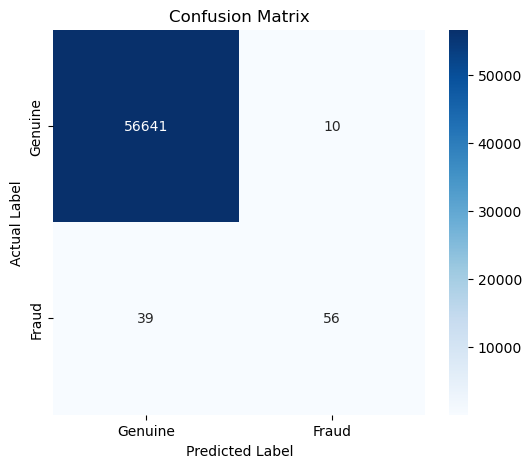

In [48]:
# Confusion Matrix Heatmap

# Visualize the confusion matrix using a heatmap for better interpretation.
plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Genuine', 'Fraud'],
    yticklabels=['Genuine', 'Fraud']
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.show()

# Classification Report

In [49]:
# Generate the classification report to evaluate the model using Precision, Recall, F1-Score, and Support.

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.85      0.59      0.70        95

    accuracy                           1.00     56746
   macro avg       0.92      0.79      0.85     56746
weighted avg       1.00      1.00      1.00     56746



# ROC-AUC Score

In [50]:
from sklearn.metrics import roc_auc_score

roc_auc = roc_auc_score(y_test, y_prob[:,1])

print("ROC-AUC Score:", round(roc_auc,4))

ROC-AUC Score: 0.9584


# ROC Curve

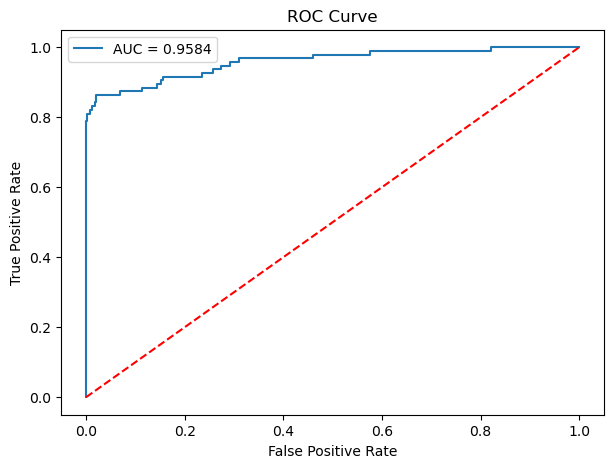

In [51]:
# Plot the Receiver Operating Characteristic (ROC) curve to visualize the model's classification performance.
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(y_test, y_prob[:,1])

plt.figure(figsize=(7,5))

plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.4f}')
plt.plot([0,1],[0,1],'r--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()

plt.show()

In [53]:
# Performance Summary
print("========== MODEL PERFORMANCE ==========")
print(f"Accuracy Score : {accuracy:.4f}")
print(f"ROC-AUC Score  : {roc_auc:.4f}")
print("=======================================")

========== MODEL PERFORMANCE ==========
Accuracy Score : 0.9991
ROC-AUC Score  : 0.9584


# Phase-6 ------------------> Conclusion

# Conclusion

# Future Scope